## Analyse de *data drift* entre train et test (Evidently)

Ce notebook a pour objectif de :

- Comparer la distribution des variables entre le **jeu d'entraînement (train)** et le **jeu de test**.
- Générer un **rapport HTML Evidently** d'analyse de data drift.
- Préparer le livrable demandé : *"Tableau HTML d’analyse de data drift réalisé à partir d’evidently".*


## 1. Imports & configuration de base

In [21]:
import os
import pandas as pd
import matplotlib.pyplot as plt

from dotenv import load_dotenv

from evidently.report import Report
from evidently.metric_preset import DataDriftPreset
from evidently import ColumnMapping

# Charger les variables d'environnement si besoin
load_dotenv()

# Chemins vers les datasets (à adapter si nécessaire)
TRAIN_PATH = "data/processed/train_mean_imputed.csv"
TEST_PATH  = "data/processed/test_mean_imputed.csv"

# Dossier de sortie pour le rapport HTML
REPORTS_DIR = "reports"
os.makedirs(REPORTS_DIR, exist_ok=True)

REPORT_PATH = os.path.join(REPORTS_DIR, "data_drift_train_vs_test.html")

TRAIN_PATH, TEST_PATH, REPORT_PATH

('data/processed/train_mean_imputed.csv',
 'data/processed/test_mean_imputed.csv',
 'reports\\data_drift_train_vs_test.html')

## 2. Chargement des données train / test

In [13]:
df_train = pd.read_csv(TRAIN_PATH)
df_test  = pd.read_csv(TEST_PATH)

print("Train shape :", df_train.shape)
print("Test shape  :", df_test.shape)

df_train.head(3)


Train shape : (307507, 84)
Test shape  : (48744, 83)


,EXT_SOURCE_3,EXT_SOURCE_2,EXT_SOURCE_1,PAYMENT_RATE,DAYS_EMPLOYED,AMT_ANNUITY,INSTAL_DPD_MEAN,CODE_GENDER,APPROVED_CNT_PAYMENT_MEAN,ACTIVE_DAYS_CREDIT_MAX,...,PREV_NAME_YIELD_GROUP_middle_MEAN,PREV_NAME_SELLER_INDUSTRY_Connectivity_MEAN,PREV_WEEKDAY_APPR_PROCESS_START_MONDAY_MEAN,PREV_PRODUCT_COMBINATION_Cash X-Sell: high_MEAN,BURO_STATUS_1_MEAN_MEAN,LANDAREA_AVG,POS_NAME_CONTRACT_STATUS_Signed_MEAN,PREV_PRODUCT_COMBINATION_Cash X-Sell: low_MEAN,PREV_WEEKDAY_APPR_PROCESS_START_WEDNESDAY_MEAN,TARGET
0,0.139376,0.262949,0.083037,0.060749,-637.0,24700.5,0.0,0,24.0,-103.00000,...,0.000000,0.0,0.0,0.0,0.255682,0.036900,0.0,0.000000,0.0,1
1,0.510856,0.622246,0.311267,0.027598,-1188.0,35698.5,0.0,1,10.0,-606.00000,...,0.666667,0.0,0.0,0.0,0.014199,0.013000,0.0,0.333333,0.0,0
2,0.729567,0.555912,0.502129,0.050000,-225.0,6750.0,0.0,0,4.0,-416.93738,...,1.000000,1.0,0.0,0.0,0.014199,0.066334,0.0,0.000000,0.0,0


## 3. Préparation : on retire la cible et on aligne les colonnes

In [14]:
TARGET_COL = "TARGET"

# On retire la cible si elle est présente
if TARGET_COL in df_train.columns:
    df_train_feat = df_train.drop(columns=[TARGET_COL])
else:
    df_train_feat = df_train.copy()

if TARGET_COL in df_test.columns:
    df_test_feat = df_test.drop(columns=[TARGET_COL])
else:
    df_test_feat = df_test.copy()

# On garde seulement l'intersection des colonnes communes
common_cols = sorted(set(df_train_feat.columns).intersection(set(df_test_feat.columns)))
df_train_feat = df_train_feat[common_cols].copy()
df_test_feat  = df_test_feat[common_cols].copy()

print("Nombre de colonnes communes utilisées :", len(common_cols))
df_train_feat.head(3)


Nombre de colonnes communes utilisées : 83


,ACTIVE_AMT_CREDIT_MAX_OVERDUE_MEAN,ACTIVE_AMT_CREDIT_SUM_LIMIT_MEAN,ACTIVE_DAYS_CREDIT_ENDDATE_MIN,ACTIVE_DAYS_CREDIT_MAX,ACTIVE_DAYS_CREDIT_UPDATE_MEAN,ACTIVE_DAYS_CREDIT_VAR,AMT_ANNUITY,ANNUITY_INCOME_PERC,APPROVED_AMT_ANNUITY_MEAN,APPROVED_AMT_DOWN_PAYMENT_MAX,...,PREV_PRODUCT_COMBINATION_Cash X-Sell: low_MEAN,PREV_WEEKDAY_APPR_PROCESS_START_MONDAY_MEAN,PREV_WEEKDAY_APPR_PROCESS_START_THURSDAY_MEAN,PREV_WEEKDAY_APPR_PROCESS_START_WEDNESDAY_MEAN,REFUSED_APP_CREDIT_PERC_MIN,REFUSED_DAYS_DECISION_MAX,REGION_POPULATION_RELATIVE,REGION_RATING_CLIENT_W_CITY,TOTALAREA_MODE,YEARS_BEGINEXPLUATATION_AVG
0,40.500,15994.282,780.0000,-103.00000,-15.50000,440860.50,24700.5,0.121978,9251.775,0.0,...,0.000000,0.0,0.0,0.0,0.867997,-728.6427,0.018801,2,0.014900,0.972200
1,0.000,810000.000,1216.0000,-606.00000,-43.00000,307208.47,35698.5,0.132217,56553.990,6885.0,...,0.333333,0.0,0.0,0.0,0.867997,-728.6427,0.003541,1,0.071400,0.985100
2,2529.067,12823.701,1011.9233,-416.93738,-132.19705,307208.47,6750.0,0.100000,5357.250,4860.0,...,0.000000,0.0,0.0,0.0,0.867997,-728.6427,0.010032,2,0.102548,0.977735


## 4. Échantillonnage

In [15]:
MAX_ROWS = 50_000 

if len(df_train_feat) > MAX_ROWS:
    df_train_sample = df_train_feat.sample(n=MAX_ROWS, random_state=42)
else:
    df_train_sample = df_train_feat.copy()

if len(df_test_feat) > MAX_ROWS:
    df_test_sample = df_test_feat.sample(n=MAX_ROWS, random_state=42)
else:
    df_test_sample = df_test_feat.copy()

print("Train utilisé :", df_train_sample.shape)
print("Test utilisé  :", df_test_sample.shape)


Train utilisé : (50000, 83)
Test utilisé  : (48744, 83)


## 5. Configuration Evidently & génération du rapport

In [16]:
# Ici on n'a pas besoin de spécifier de target/prediction pour le data drift pur.
column_mapping = ColumnMapping(
    target=None,
    prediction=None,
    numerical_features=None,   # Evidently les infère
    categorical_features=None  # Evidently les infère
)

report = Report(
    metrics=[
        DataDriftPreset()
    ]
)

report.run(
    reference_data=df_train_sample,
    current_data=df_test_sample,
    column_mapping=column_mapping
)

# Sauvegarde en HTML
report.save_html(REPORT_PATH)
print(f"Rapport Evidently sauvegardé sous : {REPORT_PATH}")


Rapport Evidently sauvegardé sous : reports\data_drift_train_vs_test.html


Interprétation du rapport Evidently

“Dataset Drift is NOT detected.” → les données de test sont cohérentes avec les données d’entraînement.

Détails importants : 

- 83 colonnes analysées

- 8 colonnes driftées

- Share of drifted columns = 0.0964 (≈ 9,6%)
→ Le seuil par défaut est 50 %, donc pas de data drift significatif.

Sur 83 features analysées, seulement 8 montrent un drift statistiquement détectable, soit environ 9,6 %. Comme le seuil de 50 % n’est pas dépassé, Evidently conclut à l’absence de drift global.
Le modèle peut donc être considéré comme stable dans le temps, et aucune action immédiate de retrain n'est nécessaire."*

## 6. Extraction des colonnes driftées (Evidently)

In [ ]:
report_dict = report.as_dict()

# On récupère le bloc "DataDriftTable"
data_drift_table = None
for m in report_dict["metrics"]:
    if m["metric"] == "DataDriftTable":
        data_drift_table = m
        break

drift_by_col = data_drift_table["result"]["drift_by_columns"]

# Liste des colonnes avec drift_detected = True
drifted_cols = [
    col_name
    for col_name, info in drift_by_col.items()
    if info.get("drift_detected", False)
]

print(f"{len(drifted_cols)} colonnes driftées :")
drifted_cols

8 colonnes driftées :


['AMT_ANNUITY',
 'BURO_STATUS_0_MEAN_MEAN',
 'BURO_STATUS_1_MEAN_MEAN',
 'DAYS_LAST_PHONE_CHANGE',
 'EXT_SOURCE_1',
 'NAME_CONTRACT_TYPE',
 'PAYMENT_RATE',
 'PREV_NAME_YIELD_GROUP_high_MEAN']

## 7. Visualisation des distributions pour les colonnes driftées

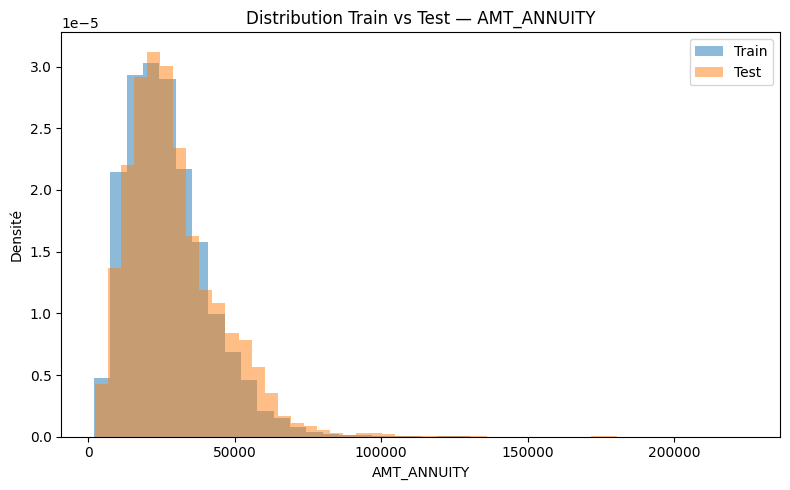

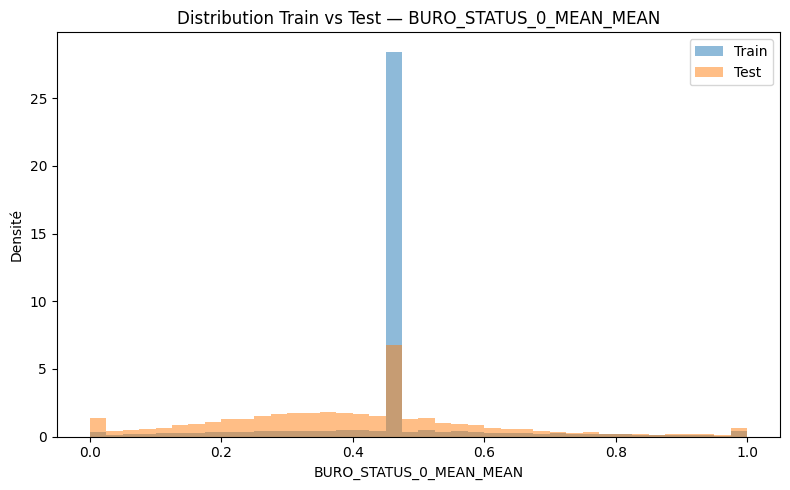

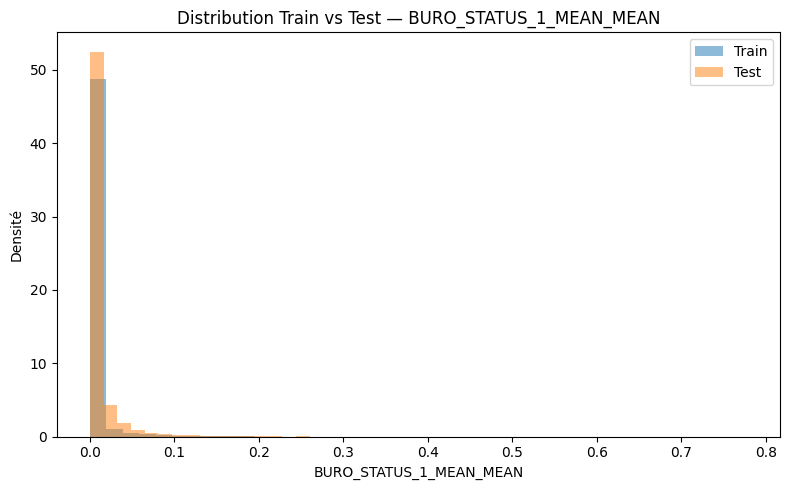

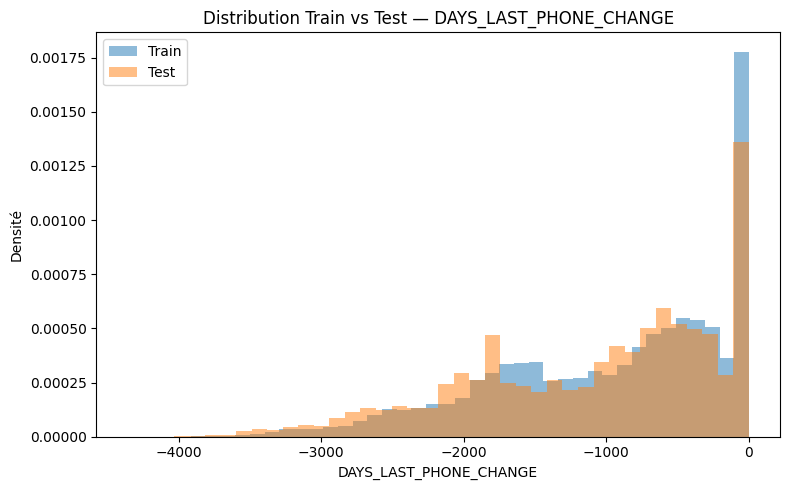

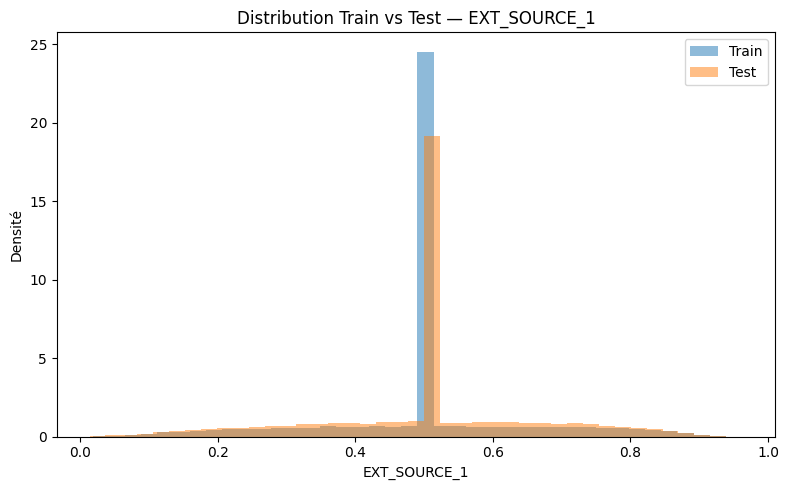

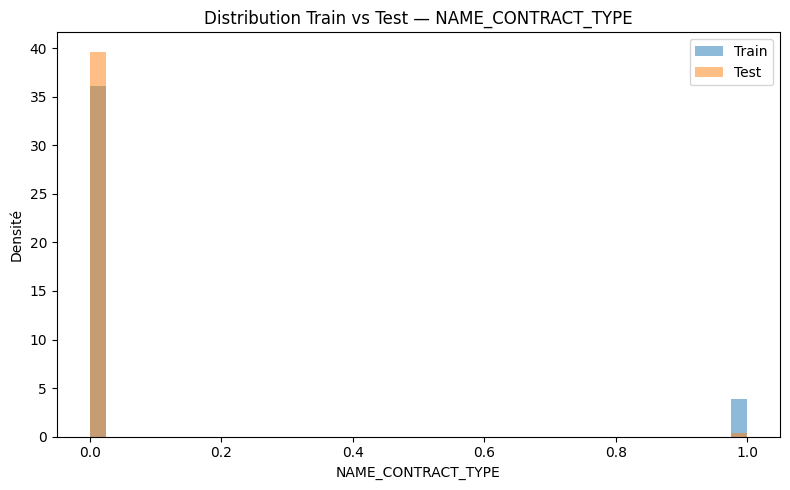

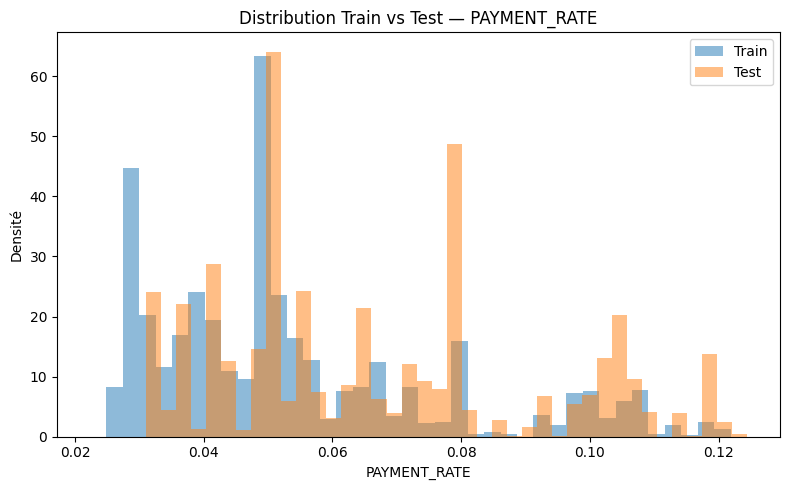

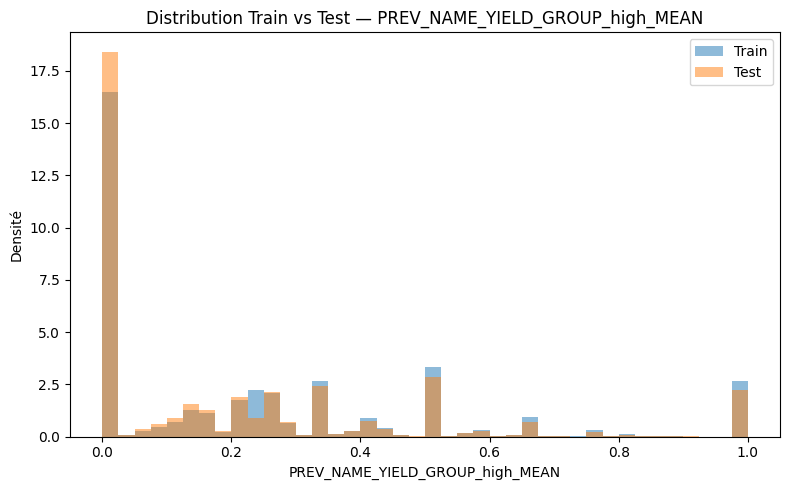

In [24]:
for col in drifted_cols:
    plt.figure(figsize=(8, 5))

    plt.hist(
        df_train_sample[col],
        bins=40,
        density=True,
        alpha=0.5,
        label="Train",
        color="tab:blue"
    )
    plt.hist(
        df_test_sample[col],
        bins=40,
        density=True,
        alpha=0.5,
        label="Test",
        color="tab:orange"
    )

    plt.title(f"Distribution Train vs Test — {col}")
    plt.xlabel(col)
    plt.ylabel("Densité")
    plt.legend()
    plt.tight_layout()

    plt.show()
